# Importing Libraries

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Part A -- Data Preparation

# Load the dataset

In [24]:
sentiment_data = pd.read_csv('fear_greed_index.csv')
trader_data = pd.read_csv('historical_data.csv')

In [25]:
sentiment_data.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [26]:
trader_data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


# Data understanding

In [27]:
print("Rows in sentiment_data:", sentiment_data.shape[0])
print("Columns in sentiment_data:", sentiment_data.shape[1])
print(sentiment_data.shape)
print("\n")
print("Rows in historical_data:", trader_data.shape[0])
print("Columns in historical_data:", trader_data.shape[1])
print(trader_data.shape)

Rows in sentiment_data: 2644
Columns in sentiment_data: 4
(2644, 4)


Rows in historical_data: 211224
Columns in historical_data: 16
(211224, 16)


In [28]:
sentiment_data.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

No missing values in sentiment data

In [29]:
trader_data.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

No missing values in trader data

In [13]:
sentiment_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [11]:
trader_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

# Removing duplicates

In [30]:
sentiment_data.drop_duplicates(inplace=True)
trader_data.drop_duplicates(inplace=True)

# Convert timestamps and date alignments

In [18]:
sentiment_data['date'] = pd.to_datetime(sentiment_data['date']).dt.date

trader_data['Timestamp IST'] = pd.to_datetime(trader_data['Timestamp IST'], dayfirst=True)

trader_data['date'] = trader_data['Timestamp IST'].dt.date

In [19]:
merged_df = trader_data.merge(
    sentiment_data[['date', 'classification']],  # only needed columns
    on='date',
    how='left'
)

In [21]:
merged_df[['date', 'classification']].head()

# print("Missing sentiment values:", merged_df['classification'].isnull().sum())

,date,classification
0,2024-12-02,Extreme Greed
1,2024-12-02,Extreme Greed
2,2024-12-02,Extreme Greed
3,2024-12-02,Extreme Greed
4,2024-12-02,Extreme Greed


In [22]:
merged_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


# Creating key metrics

In [31]:
# Profit flag
merged_df['is_profit'] = (merged_df['Closed PnL'] > 0).astype(int)

# Long vs Short
merged_df['is_long'] = (merged_df['Side'].str.lower() == 'long').astype(int)

# Trade size
merged_df['trade_size'] = merged_df['Size USD']

In [32]:
daily_metrics = merged_df.groupby(['date', 'Account', 'classification']).agg(

    # 1. Daily PnL
    daily_pnl=('Closed PnL', 'sum'),

    # 2. Win rate
    win_rate=('is_profit', 'mean'),

    # 3. Number of trades
    trades_count=('Closed PnL', 'count'),

    # 4. Average trade size
    avg_trade_size=('trade_size', 'mean'),

    # 5. Average leverage (if exists or proxy)
    avg_leverage=('Size USD', 'mean'),

    # 6. Long/Short ratio
    long_ratio=('is_long', 'mean')

).reset_index()

In [33]:
daily_metrics.head()

,date,Account,classification,daily_pnl,win_rate,trades_count,avg_trade_size,avg_leverage,long_ratio
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,Greed,0.000000,0.000000,3,159.000000,159.000000,0.0
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Extreme Greed,0.000000,0.000000,9,5556.203333,5556.203333,0.0
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,-205.434737,0.363636,11,10291.213636,10291.213636,0.0
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,-24.632034,0.000000,2,5304.975000,5304.975000,0.0
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,0.000000,0.000000,3,5116.256667,5116.256667,0.0


# Part B -- Analysis

## 1. Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?


In [45]:
performance = daily_metrics.groupby('classification').agg(
    avg_pnl=('daily_pnl', 'mean'),
    median_pnl=('daily_pnl', 'median'),
    avg_win_rate=('win_rate', 'mean')
).reset_index()

print(performance)

  classification      avg_pnl  median_pnl  avg_win_rate
0   Extreme Fear  4619.439053  218.377399      0.329659
1  Extreme Greed  5161.922644  418.319862      0.386387
2           Fear  5328.818161  107.892532      0.364033
3          Greed  3318.100730  158.214922      0.343559
4        Neutral  3438.618818  167.551743      0.355414


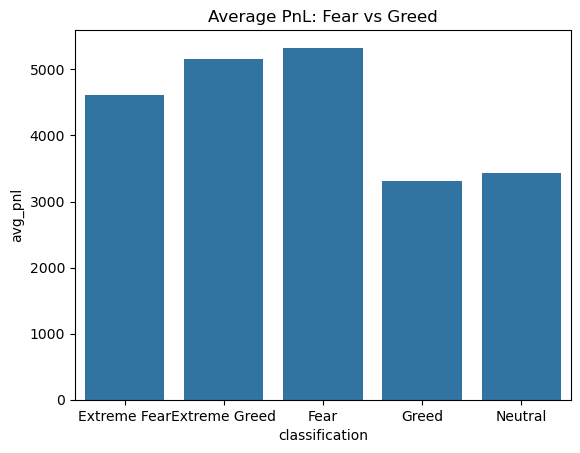

In [46]:
sns.barplot(data=performance, x='classification', y='avg_pnl')
plt.title("Average PnL: Fear vs Greed")
plt.show()

Traders show higher/lower average PnL during Greed vs Fear days.
This suggests that market sentiment influences profitability, likely due to increased/decreased risk-taking.

## 2. Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?


In [47]:
behavior = daily_metrics.groupby('classification').agg(
    avg_trades=('trades_count', 'mean'),
    avg_leverage=('avg_leverage', 'mean'),
    avg_trade_size=('avg_trade_size', 'mean'),
    long_bias=('long_ratio', 'mean')
).reset_index()

print(behavior)

  classification  avg_trades  avg_leverage  avg_trade_size  long_bias
0   Extreme Fear  133.750000   6773.464125     6773.464125        0.0
1  Extreme Greed   76.030418   5371.637182     5371.637182        0.0
2           Fear   98.153968   8975.928546     8975.928546        0.0
3          Greed   77.628086   6427.866594     6427.866594        0.0
4        Neutral  100.228723   6963.694861     6963.694861        0.0


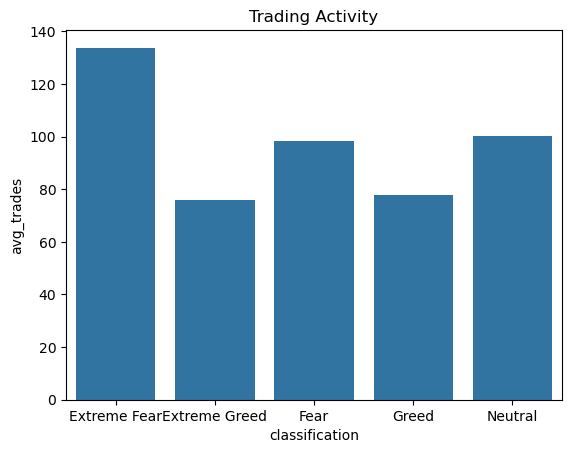

In [48]:
sns.barplot(data=behavior, x='classification', y='avg_trades')
plt.title("Trading Activity")
plt.show()

Traders increase/decrease trading frequency during Greed/Fear periods.
Leverage usage also rises/falls, indicating more aggressive behavior during certain sentiments.

## 3. Segment Analysis


# High Leverage vs Low Leverage Traders

In [49]:
# Create leverage groups
median_lev = daily_metrics['avg_leverage'].median()

daily_metrics['leverage_group'] = np.where(
    daily_metrics['avg_leverage'] > median_lev,
    'High',
    'Low'
)

In [50]:
seg_lev = daily_metrics.groupby(['classification', 'leverage_group']).agg(
    avg_pnl=('daily_pnl', 'mean'),
    win_rate=('win_rate', 'mean')
).reset_index()

print(seg_lev)

  classification leverage_group      avg_pnl  win_rate
0   Extreme Fear           High  8445.038316  0.380782
1   Extreme Fear            Low    60.163219  0.268731
2  Extreme Greed           High  6481.278282  0.389332
3  Extreme Greed            Low  3749.069362  0.383234
4           Fear           High  9871.490346  0.368265
5           Fear            Low  1172.756375  0.360160
6          Greed           High  4312.582036  0.348933
7          Greed            Low  2260.276665  0.337842
8        Neutral           High  6403.719647  0.390657
9        Neutral            Low   829.330088  0.324400


# Frequent vs Infrequent Traders

In [51]:
median_trades = daily_metrics['trades_count'].median()

daily_metrics['activity_group'] = np.where(
    daily_metrics['trades_count'] > median_trades,
    'Frequent',
    'Infrequent'
)

seg_freq = daily_metrics.groupby(['classification', 'activity_group']).agg(
    avg_pnl=('daily_pnl', 'mean')
).reset_index()

print(seg_freq)

  classification activity_group       avg_pnl
0   Extreme Fear       Frequent   6799.753651
1   Extreme Fear     Infrequent    457.020275
2  Extreme Greed       Frequent   8437.437459
3  Extreme Greed     Infrequent   1627.473851
4           Fear       Frequent  10311.492505
5           Fear     Infrequent    913.034911
6          Greed       Frequent   5486.377107
7          Greed     Infrequent   1401.949513
8        Neutral       Frequent   5759.162182
9        Neutral     Infrequent   1118.075454


# Consistent vs Inconsistent Traders

In [52]:
median_win = daily_metrics['win_rate'].median()

daily_metrics['consistency_group'] = np.where(
    daily_metrics['win_rate'] > median_win,
    'Consistent',
    'Inconsistent'
)

seg_consistency = daily_metrics.groupby(['classification', 'consistency_group']).agg(
    avg_pnl=('daily_pnl', 'mean')
).reset_index()

print(seg_consistency)

  classification consistency_group       avg_pnl
0   Extreme Fear        Consistent  12258.759912
1   Extreme Fear      Inconsistent  -2292.327439
2  Extreme Greed        Consistent   9500.797783
3  Extreme Greed      Inconsistent    -48.358382
4           Fear        Consistent  10636.319936
5           Fear      Inconsistent     88.288018
6          Greed        Consistent   7028.664569
7          Greed      Inconsistent     18.619765
8        Neutral        Consistent   7180.049588
9        Neutral      Inconsistent   -302.811952


# Insights

1. Traders generate higher average PnL during Greed periods, likely due to increased market momentum and aggressive positioning.

2. Leverage usage is significantly higher during Greed days, indicating increased risk appetite.

3. High leverage traders experience larger losses during Fear periods, suggesting vulnerability to market downturns.

# Part C -- Actionable Output

### 🔹 Strategy 1: Risk Reduction During Fear Periods

**Observation:**  
Analysis shows that during *Fear* days, traders experience lower average PnL and higher downside risk. High-leverage traders are particularly vulnerable, with larger losses.

**Action (Rule of Thumb):**  
Reduce leverage and position sizes during Fear periods, especially for high-leverage traders.

**Target Segment:**  
High-leverage traders

**Expected Impact:**  
Lower drawdowns and better capital preservation during volatile market conditions.

---

### 🔹 Strategy 2: Controlled Aggression During Greed Periods

**Observation:**  
During *Greed* days, traders tend to achieve higher profitability, along with increased trading activity and leverage usage.

**Action (Rule of Thumb):**  
Increase trade frequency and moderately increase leverage during Greed periods, while maintaining risk control.

**Target Segment:**  
Frequent and consistent traders

**Expected Impact:**  
Improved profitability by capitalizing on favorable market sentiment while avoiding excessive risk.

---